In [4]:
################################################################################
# Remove columns with mean 0 and remove duplicate rows
################################################################################

import numpy as np
import os
import pandas as pd
from tqdm import tqdm
from pathlib import Path

path = Path('/Users/S4160163/Documents/Projects/RAG Paper/data/cic-iot/CSV')
dfs = []

# Recursively find all CSV files in subdirectories
for csv_file in tqdm(path.rglob('*.csv'), ncols=100, desc='Reading CSVs...'):
    df_temp = pd.read_csv(csv_file)
    # Extract label from directory name (same approach as 0-analysis.ipynb)
    label = csv_file.parent.name.replace('_Final', '')
    df_temp['label'] = label

    # Sample up to 10000 rows (with replacement if file is smaller)
    sample_size = min(10000, len(df_temp))
    dfs.append(df_temp.sample(n=sample_size, random_state=42, replace=(len(df_temp) < 10000)))

if not dfs:
    raise FileNotFoundError(f"No CSV files found in {path}")

df = pd.concat(dfs, ignore_index=True)

# remove columns if mean is 0
columns_to_drop = []
for c in df.select_dtypes(include=[np.number]).columns:
    if df[c].mean() == 0:
        columns_to_drop.append(c)
print("Columns to drop: ", columns_to_drop)

# get df with removed columns
df_with_dropped_columns = df.drop(columns_to_drop, axis=1)
print("Number of columns before removing columns: ", len(df.columns))
print("Number of columns after removing columns: ", len(df_with_dropped_columns.columns))

# remove duplicate rows
df_no_duplicates = df_with_dropped_columns.drop_duplicates()
print("Length of dataset before removing duplicates: ", len(df_with_dropped_columns))
print("Length of dataset after removing duplicates: ", len(df_no_duplicates))

# Create data directory if it doesn't exist
os.makedirs(os.getcwd() + '/data', exist_ok=True)

# save to csv
df_no_duplicates.to_csv(os.getcwd() + '/data/population.csv', index=False)

Reading CSVs...: 309it [00:45,  6.74it/s]


Columns to drop:  []
Number of columns before removing columns:  40
Number of columns after removing columns:  40
Length of dataset before removing duplicates:  3046573
Length of dataset after removing duplicates:  2403362


In [5]:
################################################################################
# Split and save dataset
################################################################################

import os
import pandas as pd

# Create data directory if it doesn't exist
os.makedirs(os.getcwd() + '/data', exist_ok=True)

df = pd.read_csv(os.getcwd() + '/data/population.csv', low_memory=False)

sample_size = 100000

benign_df = df[df['label'] == 'Benign']
attack_df = df[df['label'] != 'Benign']

# Keep original class ratio target, but avoid crashing when one class is smaller than requested
benign_target = min(10800, len(benign_df))
attack_target = min(sample_size - benign_target, len(attack_df))

sample_df = pd.concat([
    benign_df.sample(n=benign_target, random_state=42, replace=False),
    attack_df.sample(n=attack_target, random_state=42, replace=False)
])

print("Length of dataset: ", len(sample_df))
sample_df.to_csv(os.getcwd() + f'/data/sample-{sample_size}-2.csv', index=False)

Length of dataset:  100000


Text(0.5, 1.0, 'Record Count')

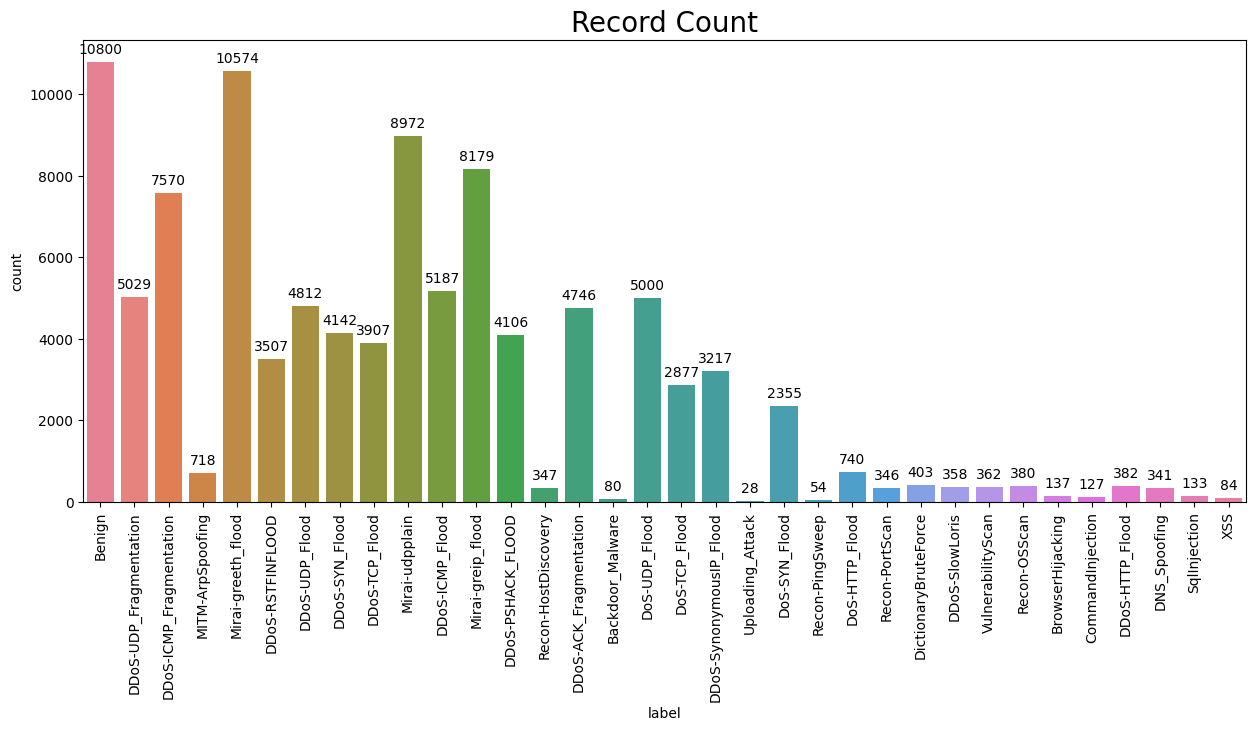

In [6]:
################################################################################
# Class distribution
################################################################################

import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

sample_size = 100000

saved_sample_df = pd.read_csv(os.getcwd() + f'/data/sample-{sample_size}-2.csv', low_memory=False)

plt.figure(figsize=(15, 6))
plt.xticks(rotation=90)
s = sns.countplot(data=saved_sample_df, x='label', hue='label')
for p in s.patches:
    s.annotate(format(p.get_height(), '.0f'), 
               (p.get_x() + p.get_width() / 2., p.get_height()), 
               ha = 'center', va = 'center', 
               xytext = (0, 9), 
               textcoords = 'offset points')
plt.title('Record Count', fontsize=20)

In [8]:
################################################################################
# Load dataset and split it into training and test set
################################################################################

import pandas as pd
import os
from tabulate import tabulate

sample_size = 100000

# Load dateset
df = pd.read_csv(os.getcwd() + f'/data/sample-{sample_size}-2.csv')

# Split dataset according to attack type
normal_df = df[df['label'] == 'Benign']
attack_df = df[df['label'] != 'Benign']

# Drop columns
normal_df = normal_df.drop(columns=['label'])
attack_df = attack_df.drop(columns=['label'])

# Split dataset into training and test set
normal_df_train = normal_df.sample(frac=0.8, random_state=42)
normal_df_test = normal_df.drop(normal_df_train.index)
attack_df_train = attack_df.sample(frac=0.8, random_state=42)
attack_df_test = attack_df.drop(attack_df_train.index)

# Print dataset sizes in a table
data = [
    ["Normal", normal_df.shape[0], normal_df_train.shape[0], normal_df_test.shape[0]],
    ["Attack", attack_df.shape[0], attack_df_train.shape[0], attack_df_test.shape[0]]
]
print(tabulate(data, headers=["Atack type", "Total", "Train", "Test"], tablefmt="grid"))

+--------------+---------+---------+--------+
| Atack type   |   Total |   Train |   Test |
+==============+=========+=========+========+
| Normal       |   10800 |    8640 |   2160 |
+--------------+---------+---------+--------+
| Attack       |   89200 |   71360 |  17840 |
+--------------+---------+---------+--------+


In [ ]:
################################################################################
# Add documents to vector store
################################################################################

from sentence_transformers import SentenceTransformer
from langchain_chroma import Chroma
from langchain_core.documents import Document
from tqdm import tqdm
import numpy as np

# Initialize embeddings using SentenceTransformer directly
model = SentenceTransformer('all-mpnet-base-v2')

# Create embedding function for Chroma
def embed_function(texts):
    if isinstance(texts, str):
        texts = [texts]
    embeddings = model.encode(texts, convert_to_numpy=True)
    return embeddings.tolist()

# Initialize vector store
vector_store = Chroma(
    collection_name="cic-iot",
    embedding_function=embed_function, 
    persist_directory=f"./vector-stores/chroma-db-{sample_size}-2")

# Add batched documents to vector store
batch_size = 16
total_normal_documents = normal_df_train.shape[0]
total_attack_documents = attack_df_train.shape[0]

for i in tqdm(range(0, total_normal_documents, batch_size), ncols=100, desc="Adding normal documents to vector store"):
    documents = [Document(page_content=str(normal_df_train.iloc[i+j].to_list()), metadata={"source": "cic-iot", "label": "normal"}) for j in range(min(batch_size, total_normal_documents-i))]
    vector_store.add_documents(documents)

for i in tqdm(range(0, total_attack_documents, batch_size), ncols=100, desc="Adding attack documents to vector store"):
    documents = [Document(page_content=str(attack_df_train.iloc[i+j].to_list()), metadata={"source": "cic-iot", "label": "attack"}) for j in range(min(batch_size, total_attack_documents-i))]
    vector_store.add_documents(documents)

print(f"Total number of documents added: {total_attack_documents+total_normal_documents}")

In [ ]:
################################################################################
# Add documents to vector store (test set)
################################################################################

from sentence_transformers import SentenceTransformer
from langchain_chroma import Chroma
from langchain_core.documents import Document
from tqdm import tqdm
import numpy as np

# Initialize embeddings using SentenceTransformer directly
model = SentenceTransformer('all-mpnet-base-v2')

# Create embedding function for Chroma
def embed_function(texts):
    if isinstance(texts, str):
        texts = [texts]
    embeddings = model.encode(texts, convert_to_numpy=True)
    return embeddings.tolist()

# Initialize vector store
vector_store = Chroma(
    collection_name="cic-iot-test",
    embedding_function=embed_function, 
    persist_directory=f"./vector-stores/chroma-db-{sample_size}-2-test")

# Add batched documents to vector store
batch_size = 16
total_normal_documents = normal_df_test.shape[0]
total_attack_documents = attack_df_test.shape[0]

for i in tqdm(range(0, total_normal_documents, batch_size), ncols=100, desc="Adding normal documents to vector store"):
    documents = [Document(page_content=str(normal_df_test.iloc[i+j].to_list()), metadata={"source": "cic-iot-test", "label": "normal"}) for j in range(min(batch_size, total_normal_documents-i))]
    vector_store.add_documents(documents)

for i in tqdm(range(0, total_attack_documents, batch_size), ncols=100, desc="Adding attack documents to vector store"):
    documents = [Document(page_content=str(attack_df_test.iloc[i+j].to_list()), metadata={"source": "cic-iot-test", "label": "attack"}) for j in range(min(batch_size, total_attack_documents-i))]
    vector_store.add_documents(documents)

print(f"Total number of documents added: {total_attack_documents+total_normal_documents}")